In [127]:
import librosa
import matplotlib.pyplot as plt
import librosa.display

print("Libraries imported successfully")

Libraries imported successfully


In [128]:
file_path = "../dataset/Data/genres_original/blues/blues.00000.wav"
signal, sr = librosa.load(file_path, duration=5, sr=None)

print("Sampling Rate:", sr)
print("Signal Length:", len(signal))
print("First 10 Samples:", signal[:10])

Sampling Rate: 22050
Signal Length: 110250
First 10 Samples: [ 0.00732422  0.01660156  0.00762939 -0.00350952 -0.0022583  -0.0093689
 -0.02267456 -0.02236938 -0.03128052 -0.04330444]


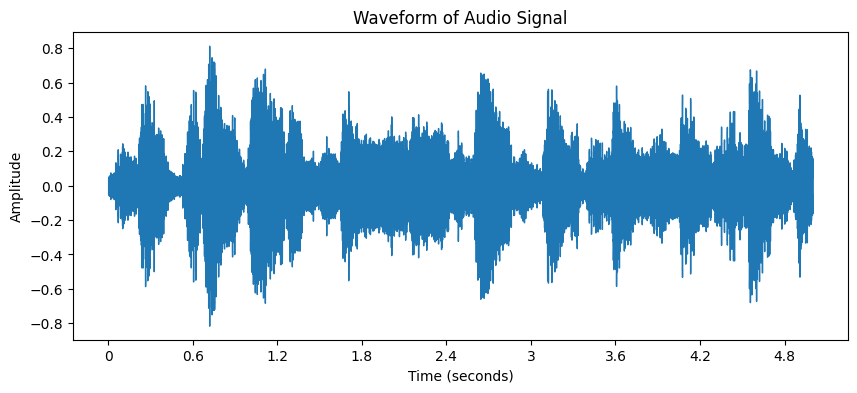

In [129]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(signal, sr=sr)
plt.title("Waveform of Audio Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [130]:
import os
print("Current working directory:", os.getcwd())

Current working directory: c:\Music_Genre_Project\notebooks


In [131]:
mfcc = librosa.feature.mfcc( y=signal, sr=sr ,n_mfcc=13 )
print(mfcc.shape)

(13, 216)


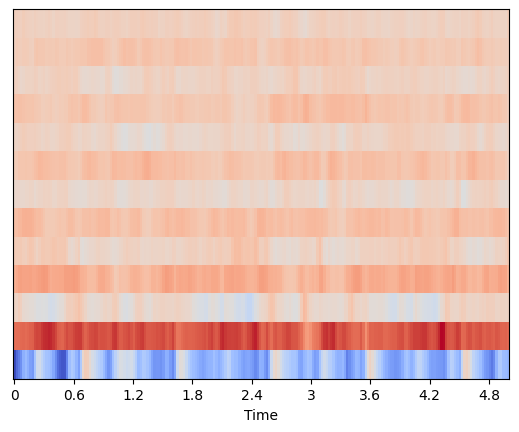

In [132]:
librosa.display.specshow(mfcc, x_axis='time')

In [133]:
spectral_centroid=librosa.feature.spectral_centroid(y=signal,sr=sr)
print(spectral_centroid.shape)
print(spectral_centroid.mean())

(1, 216)
1778.8404173340034


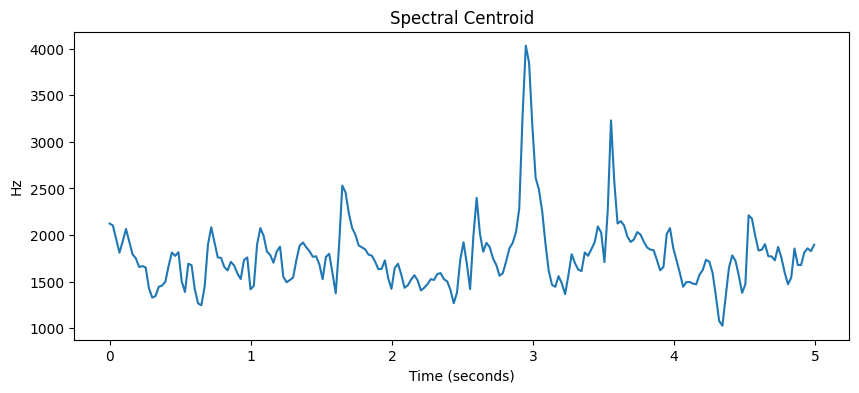

In [134]:
plt.figure(figsize=(10, 4))
frames = range(len(spectral_centroid[0]))
times = librosa.frames_to_time(frames, sr=sr)

plt.plot(times, spectral_centroid[0])
plt.title("Spectral Centroid")
plt.xlabel("Time (seconds)")
plt.ylabel("Hz")
plt.show()

In [135]:
zcr = librosa.feature.zero_crossing_rate(y=signal)

print(zcr.shape)
print(zcr.mean())

(1, 216)
0.0839527271412037


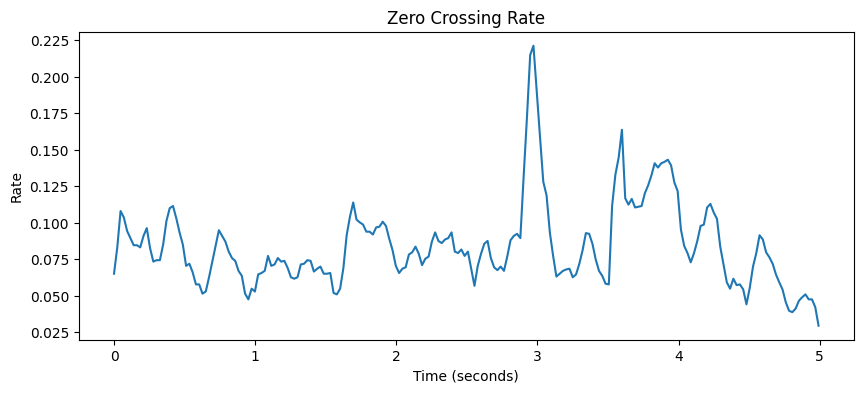

In [136]:
plt.figure(figsize=(10, 4))

frames = range(len(zcr[0]))
times = librosa.frames_to_time(frames, sr=sr)

plt.plot(times, zcr[0])
plt.title("Zero Crossing Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("Rate")
plt.show()

In [137]:
mfcc_mean = mfcc.mean(axis=1)
centroid_mean = spectral_centroid.mean()
zcr_mean = zcr.mean()

import numpy as np

feature_vector = np.hstack([mfcc_mean, centroid_mean, zcr_mean])

print(feature_vector)
print("Length:", len(feature_vector))

[-1.19217590e+02  1.24338333e+02 -2.28387909e+01  4.20747414e+01
 -7.01125526e+00  1.99872608e+01 -1.60268688e+01  1.78848057e+01
 -1.25538063e+01  1.23625450e+01 -9.08980656e+00  8.99422169e+00
 -5.61132002e+00  1.77884042e+03  8.39527271e-02]
Length: 15


In [138]:
import os
import numpy as np 

In [ ]:
X = []
y = []

dataset_path = "../dataset/Data/genres_original"
genres = ["blues","classical","country","disco","hiphop","jazz","metal","pop","reggae","rock"]

for genre in genres:
    genre_folder = os.path.join(dataset_path, genre)
    print("Checking:", genre_folder) 
    
    files = os.listdir(genre_folder)
    print("Files found:", len(files))
    
    for file in files:
        file_path = os.path.join(genre_folder, file)
        
        try:
            signal, sr = librosa.load(file_path, duration=5)
            
            # --- MFCC ---
            mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
            mfcc_mean = mfcc.mean(axis=1)

           
            # --- CHROMA ---
            #chroma = librosa.feature.chroma_stft(y=signal, sr=sr) 
           # chroma_mean = chroma.mean(axis=1)

            # --- SPECTRAL CENTROID ---
            spectral_centroid = librosa.feature.spectral_centroid(y=signal, sr=sr)
            centroid_mean = spectral_centroid.mean()

            # --- ZCR ---
            zcr = librosa.feature.zero_crossing_rate(y=signal)
            zcr_mean = zcr.mean()

            # --- FINAL FEATURE VECTOR ---
            feature_vector = np.hstack([
              mfcc_mean,
              # chroma_mean, 
              centroid_mean,
              zcr_mean
            ])
            X.append(feature_vector)
            y.append(genre)
        
        except Exception as e:
                print("Error in:", file_path)
                print(e)

Checking: ../dataset/Data/genres_original\blues
Files found: 100
Checking: ../dataset/Data/genres_original\classical
Files found: 100
Checking: ../dataset/Data/genres_original\country
Files found: 100
Checking: ../dataset/Data/genres_original\disco
Files found: 100
Checking: ../dataset/Data/genres_original\hiphop
Files found: 100
Checking: ../dataset/Data/genres_original\jazz
Files found: 100


C:\Users\rosha\AppData\Local\Temp\ipykernel_20612\935799389.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, duration=5)
C:\Users\rosha\AppData\Roaming\Python\Python313\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error in: ../dataset/Data/genres_original\jazz\jazz.00054.wav

Checking: ../dataset/Data/genres_original\metal
Files found: 100
Checking: ../dataset/Data/genres_original\pop
Files found: 100
Checking: ../dataset/Data/genres_original\reggae
Files found: 100
Checking: ../dataset/Data/genres_original\rock
Files found: 100


In [140]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (999, 27)
y shape: (999,)


In [141]:
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler
test_index = 564
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_song = X_scaled[test_index]
distances = euclidean_distances([test_song], X_scaled)[0]


In [142]:
nearest_indices = np.argsort(distances)[1:15]

In [143]:
print("Nearest indices:", nearest_indices)
print("Nearest genres:", y[nearest_indices])

Nearest indices: [539  24  27 541 540 566 533 551 947 542 246 216 107 571]
Nearest genres: ['jazz' 'blues' 'blues' 'jazz' 'jazz' 'jazz' 'jazz' 'jazz' 'rock' 'jazz'
 'country' 'country' 'classical' 'jazz']


In [144]:
from collections import Counter

nearest_genres = y[nearest_indices]

predicted_genre = Counter(nearest_genres).most_common(1)[0][0]

print("Predicted:", predicted_genre)
print("Actual:", y[test_index])

Predicted: jazz
Actual: jazz


In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

from collections import Counter
import numpy as np

correct = 0

for test_index in range(len(X_scaled)):
    
    test_song = X_scaled[test_index]
    
    distances = euclidean_distances([test_song], X_scaled)[0]
    
    nearest_indices = np.argsort(distances)[1:15]  
    
    nearest_genres = y[nearest_indices]
    
    predicted = Counter(nearest_genres).most_common(1)[0][0]
    
    if predicted == y[test_index]:
        correct += 1

accuracy = correct / len(X_scaled)

print("Accuracy:", accuracy)

Accuracy: 0.5445445445445446
